In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


%matplotlib widget

In [15]:
def fitting_function(x, a, b, c):
    return a * x**2 + b * x + c

def fitting_function(x, a, b):
    return a * x + b

In [82]:
L = np.array([[90, 80, 70], [60, 50, 40], [30, 20, 10]])
f0_lone = np.array([4.06371, 4.37046, 4.76296, 5.21632, 5.70886, 5.91986, 6.22431, 6.91921, 7.87878])
f0_array = np.array([4.06037, 4.36609, 4.75709, 5.20837, 5.69937, 5.90939, 6.21249, 6.90278, 7.85443])
df_f = (f0_array - f0_lone) / f0_lone
id = np.array([[6, 7, 8], [3, 4, 5], [0, 1, 2]], dtype=int)

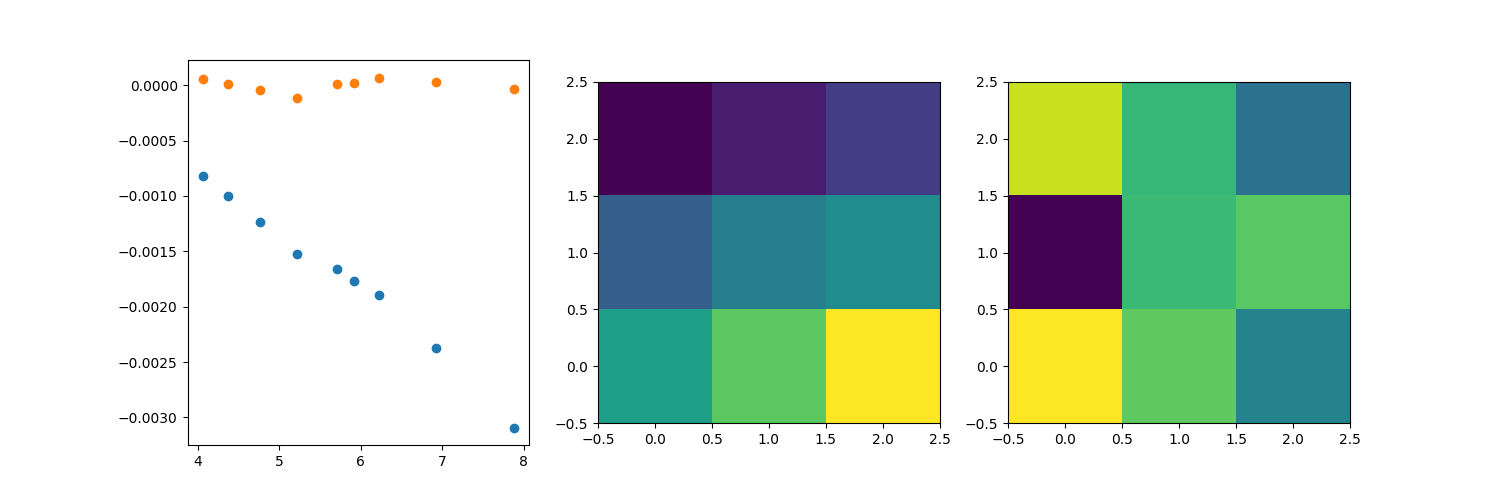

In [83]:
fig, axes = plt.subplot_mosaic('abc', figsize=(15, 5))
ax = axes['a']
ax.scatter(f0_lone, df_f)
# Define a fitting function


# Fit df_f as a function of f0_lone
params, _ = curve_fit(fitting_function, f0_lone, df_f)

# Subtract the fitted values from df_f
fitted_values = fitting_function(f0_lone, *params)
df_f_adjusted = df_f - fitted_values

# Update the scatter plot with adjusted values
ax.scatter(f0_lone, df_f_adjusted)
ax = axes['b']
ax.imshow(f0_lone[id], origin='lower')
ax = axes['c']
ax.imshow(df_f_adjusted[id], origin='lower')

In [11]:
L = np.array([96, 88, 80, 72, 64, 56, 48, 40, 32, 16, 8])
f0_lone = np.array([4.06722, 4.28029, 4.53686, 4.79523, 4.99459, 5.08725, 5.3182, 6.13543, 7.04793, 7.80277, 8.38633, 8.83583])
f0_array_gp = np.array([4.06349, 4.27662, 4.53062, 4.78877, 4.98738, 5.08016, 5.31163, 6.12346, 7.03274, 7.77977, 8.36139, 8.79728])
f0_array_holes = np.array([4.06349, 4.27667, 4.53062, 4.78888, 4.98738, 5.08017, 5.31163, 6.12346, 7.03294, 7.77977, 8.3621, 8.79728])
df_f_gp = (f0_array_gp - f0_lone) / f0_lone * 1e3
df_f_holes = (f0_array_holes - f0_lone) / f0_lone * 1e3
id = np.array([[0, 4, 8], [9, 5, 1], [2, 6, 10], [11, 7, 3]], dtype=int)

In [16]:
L = np.array([96, 88, 80, 72, 64, 56, 48, 40, 32, 16, 8])
f0_lone = np.array([3.91992, 4.11376, 4.36633, 4.67357, 5.02233, 5.40095, 5.77216, 5.79929, 6.21023, 6.4749, 7.30895, 8.00698])
f0_array_gp = np.array([3.91913, 4.11369, 4.36452, 4.67332, 5.02245, 5.40132, 5.77378, 5.80244, 6.21091, 6.47655, 7.31275, 8.00703])
f0_array_holes = np.array([3.91913, 4.11374, 4.36452, 4.67336, 5.02245, 5.40132, 5.77378, 5.80245, 6.21091, 6.47655, 7.31322, 8.00703])
df_f_gp = (f0_array_gp - f0_lone) / f0_lone * 1e3
df_f_holes = (f0_array_holes - f0_lone) / f0_lone * 1e3
id = np.array([[0, 4, 8], [9, 5, 1], [2, 6, 10], [11, 7, 3]], dtype=int)

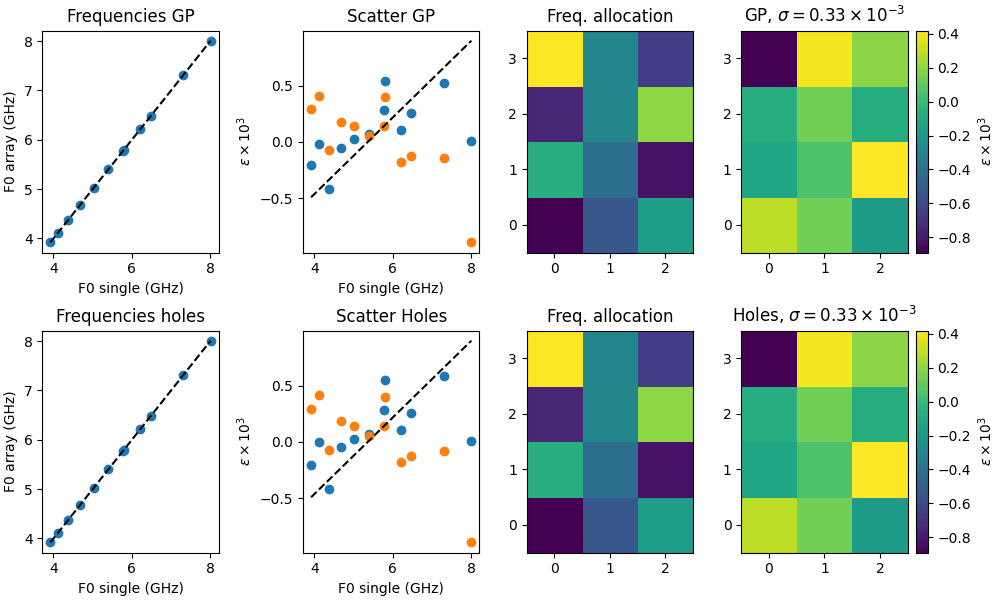

In [20]:

fig, axes = plt.subplot_mosaic('abcd;efgh', figsize=(10, 6), constrained_layout=True)
ax = axes['a']
ax.plot(f0_lone, f0_lone, 'k--')
ax.scatter(f0_lone, f0_array_gp, label='Array GP')
ax.set_xlabel('F0 single (GHz)')
ax.set_ylabel('F0 array (GHz)')
ax.set_title('Frequencies GP')

ax = axes['e']
ax.plot(f0_lone, f0_lone, 'k--')
ax.scatter(f0_lone, f0_array_holes, label='Array holes')
ax.set_xlabel('F0 single (GHz)')
ax.set_ylabel('F0 array (GHz)')
ax.set_title('Frequencies holes')

range = [2, 5, 6, 9]
# range = np.arange(12)
ax = axes['b']
ax.scatter(f0_lone, df_f_gp)
params_gp, _ = curve_fit(fitting_function, f0_lone[range], df_f_gp[range])
fitted_values_gp = fitting_function(f0_lone, *params_gp)
df_f_adj_gp = df_f_gp - fitted_values_gp
ax.plot(f0_lone, fitted_values_gp, 'k--', marker='None', label='Fitted GP')
ax.scatter(f0_lone, df_f_adj_gp)
ax.set_title('Scatter GP')
ax.set_xlabel('F0 single (GHz)')
ax.set_ylabel('$\\epsilon\\times 10^3$')

ax = axes['f']
ax.scatter(f0_lone, df_f_holes)
params_holes, _ = curve_fit(fitting_function, f0_lone[range], df_f_holes[range])
fitted_values_holes = fitting_function(f0_lone, *params_holes)
df_f_adj_holes = df_f_holes - fitted_values_holes
ax.plot(f0_lone, fitted_values_holes, 'k--', marker='None', label='Fitted GP')
ax.scatter(f0_lone, df_f_adj_holes)
ax.set_title('Scatter Holes')
ax.set_xlabel('F0 single (GHz)')
ax.set_ylabel('$\\epsilon\\times 10^3$')

ax = axes['c']
ax.imshow(f0_lone[id], origin='lower')
ax.set_title('Freq. allocation')
ax = axes['g']
ax.imshow(f0_lone[id], origin='lower')
ax.set_title('Freq. allocation')

ax = axes['d']
ax.set_title('GP, $\\sigma=%.2f\\times 10^{-3}$' % np.std(df_f_adj_gp))
fig.colorbar(ax.imshow(df_f_adj_holes[id], origin='lower'), orientation='vertical', label='$\\epsilon\\times 10^3$')

ax = axes['h']
ax.set_title('Holes, $\\sigma=%.2f\\times 10^{-3}$' % np.std(df_f_adj_holes))
fig.colorbar(ax.imshow(df_f_adj_holes[id], origin='lower'), orientation='vertical', label='$\\epsilon\\times 10^3$')
